In [3]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn tensorflow matplotlib seaborn


In [54]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping


In [55]:
df = pd.read_csv("drug_recommendation.csv")

df = df[['Age', 'Gender', 'Symptoms', 'Disease', 'Drug']]
df.dropna(inplace=True)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (50000, 5)


,Age,Gender,Symptoms,Disease,Drug
0,61,Male,Body pain,Migraine,Sumatriptan
1,5,Female,"Abdominal pain, Vomiting",Gastritis,Omeprazole
2,4,Male,Nausea,Allergy,Cetirizine
3,43,Female,"Fever, Vomiting",Asthma,Salbutamol
4,57,Female,"Cold, Fever, Breathlessness",COVID-19,Azithromycin


In [56]:
le_gender = LabelEncoder()
le_disease = LabelEncoder()
le_drug = LabelEncoder()

df['Gender'] = le_gender.fit_transform(df['Gender'])
df['Disease'] = le_disease.fit_transform(df['Disease'])
df['Drug'] = le_drug.fit_transform(df['Drug'])


In [57]:
noise_ratio = 0.02
n_noisy = int(noise_ratio * len(df))

np.random.seed(42)
idx = np.random.choice(df.index, n_noisy, replace=False)
df.loc[idx, 'Drug'] = np.random.choice(df['Drug'], n_noisy)

print("Noise added to samples:", n_noisy)


Noise added to samples: 1000


In [58]:
vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=2200,
    output_mode='tf-idf'
)

vectorizer.adapt(df['Symptoms'])
symptom_vectors = vectorizer(df['Symptoms']).numpy()


In [59]:
X_numeric = df[['Age', 'Gender', 'Disease']].values
X = np.hstack((symptom_vectors, X_numeric))

y = to_categorical(df['Drug'])

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (50000, 17)
y shape: (50000, 10)


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    shuffle=True
)


In [61]:
model = Sequential([
    Dense(96, activation='relu',
          kernel_regularizer=l2(0.002),
          input_shape=(X_train.shape[1],)),
    Dropout(0.35),

    Dense(48, activation='relu',
          kernel_regularizer=l2(0.002)),
    Dropout(0.35),

    Dense(y.shape[1], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 96)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │           490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,874 (26.85 KB)

 Trainable params: 6,874 (26.85 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=1,
    restore_best_weights=False
)


In [63]:
history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.1109 - loss: 4.5441 - val_accuracy: 0.2160 - val_loss: 2.1364
Epoch 2/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2058 - loss: 2.0730 - val_accuracy: 0.4265 - val_loss: 1.4846
Epoch 3/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3651 - loss: 1.5666 - val_accuracy: 0.7305 - val_loss: 1.0726
Epoch 4/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5188 - loss: 1.2251 - val_accuracy: 0.9516 - val_loss: 0.7229
Epoch 5/12
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6526 - loss: 0.9692 - val_accuracy: 0.8967 - val_loss: 0.5839


In [64]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Test Accuracy: 84.04%


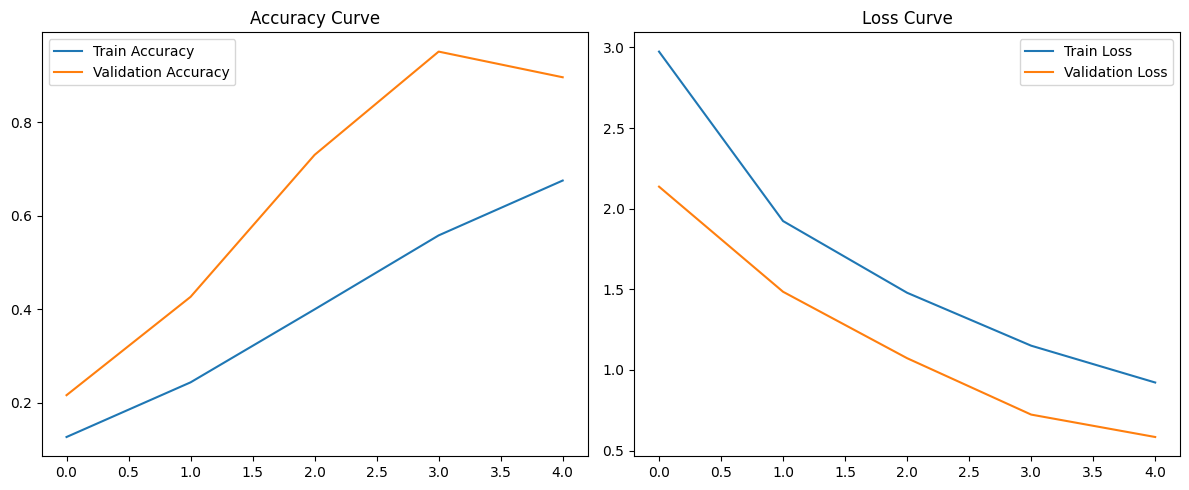

In [65]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")

plt.tight_layout()
plt.show()


In [66]:
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred))


391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1165
           1       0.93      0.93      0.93      1240
           2       0.93      0.93      0.93      1311
           3       0.93      0.93      0.93      1289
           4       0.92      0.93      0.93      1246
           5       0.93      0.93      0.93      1229
           6       0.94      0.93      0.93      1270
           7       0.93      0.92      0.93      1281
           8       0.93      0.93      0.93      1220
           9       0.47      0.93      0.63      1249

    accuracy                           0.84     12500
   macro avg       0.79      0.83      0.81     12500
weighted avg       0.80      0.84      0.81     12500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


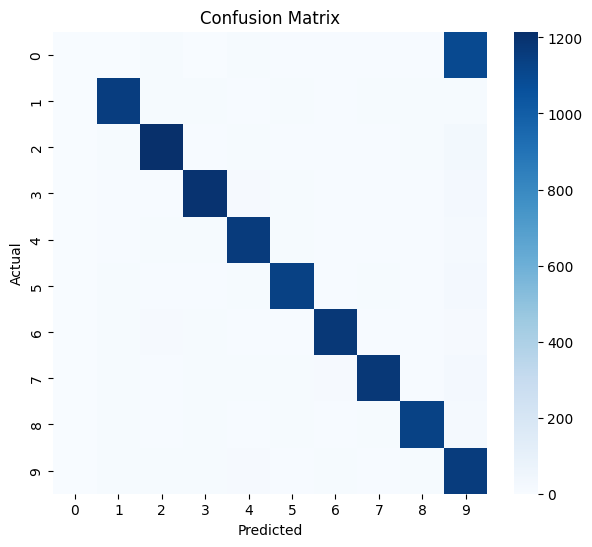

In [67]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [69]:
def recommend_drug(age, gender, symptoms, disease):
    g = le_gender.transform([gender])[0]
    d = le_disease.transform([disease])[0]

    s_vec = vectorizer([symptoms]).numpy()
    input_data = np.hstack((s_vec, [[age, g, d]]))

    pred = model.predict(input_data)
    drug_idx = np.argmax(pred)

    return le_drug.inverse_transform([drug_idx])[0]


In [70]:
recommend_drug(
    age=35,
    gender='Male',
    symptoms='Fever, headache, nausea',
    disease='Flu'
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


'Paracetamol'